In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df=pd.read_csv("young_adult_heart_disease_brfss_2021.csv")

In [ ]:
df.shape

(206361, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206361 entries, 0 to 206360
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      206361 non-null  float64
 1   _AGEG5YR                 206361 non-null  float64
 2   Sex                      206361 non-null  float64
 3   _MICHD                   206361 non-null  float64
 4   CVDINFR4                 206361 non-null  float64
 5   CVDCRHD4                 206361 non-null  float64
 6   Smoking_History          195126 non-null  float64
 7   Current_Smoking          67566 non-null   float64
 8   Exercise                 206361 non-null  float64
 9   Mentally_Unhealthy_Days  206361 non-null  float64
 10  Fruit_Intake             188308 non-null  float64
 11  Fruit_Juice_Intake       187404 non-null  float64
 12  Green_Vegetable_Intake   186748 non-null  float64
 13  Other_Vegetable_Intake   184793 non-null  float64
 14  BMI 

In [ ]:
df = df.drop(columns=["_AGEG5YR","_MICHD","CVDINFR4","CVDCRHD4"])
df.rename(columns={"CHOLCHK3": "Time_Since_Cholesterol_Check"},inplace=True)
print(df.shape)

(206361, 18)


In [ ]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
print("Missing age:", df["Age"].isna().sum())
print("Age range:", df["Age"].min(), df["Age"].max())

Missing age: 0
Age range: 18.0 55.0


In [ ]:
print(df["Heart_Disease"].value_counts())
print(df["Heart_Disease"].value_counts(normalize=True) * 100)

Heart_Disease
0    201382
1      4979
Name: count, dtype: int64
Heart_Disease
0    97.587238
1     2.412762
Name: proportion, dtype: float64


In [ ]:
df["Mentally_Unhealthy_Days"] = df[
    "Mentally_Unhealthy_Days"
].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})

print(df["Mentally_Unhealthy_Days"].describe())
print("Missing:", df["Mentally_Unhealthy_Days"].isna().sum())

count    203216.000000
mean          5.276189
std           8.801885
min           0.000000
25%           0.000000
50%           0.000000
75%           6.000000
max          30.000000
Name: Mentally_Unhealthy_Days, dtype: float64
Missing: 3145


In [ ]:
df["Sex"] = df["Sex"].map({
    1: 1,  # Male
    2: 0   # Female
})

df["Smoking_History"] = df["Smoking_History"].replace({
    1: 1,
    2: 0,
    7: np.nan,
    9: np.nan
})

df["Current_Smoking"] = df["Current_Smoking"].replace({
    1: 2,  # Daily
    2: 1,  # Some days
    3: 0,  # Not currently
    7: np.nan,
    9: np.nan
})

df.loc[
    (df["Smoking_History"] == 0) &
    (df["Current_Smoking"].isna()),
    "Current_Smoking"
] = 0

df["Exercise"] = df["Exercise"].replace({
    1: 1,
    2: 0,
    7: np.nan,
    9: np.nan
})

df["Diabetes"] = df["Diabetes"].replace({
    1: 1,       # Diabetes
    2: 0,       # During pregnancy only
    3: 0,       # No
    4: 1,       # Prediabetes/borderline
    7: np.nan,
    9: np.nan
})

df["High_Blood_Pressure"] = df[
    "High_Blood_Pressure"
].replace({
    1: 1,       # Yes
    2: 0,       # During pregnancy only
    3: 0,       # No
    4: 1,       # Borderline
    7: np.nan,
    9: np.nan
})

df["High_Cholesterol"] = df[
    "High_Cholesterol"
].replace({
    1: 1,
    2: 0,
    7: np.nan,
    9: np.nan
})

df.loc[
    ~df["BMI"].between(10, 70),
    "BMI"
] = np.nan

In [ ]:
df = df.drop(columns=["BMI_Category"])

In [ ]:
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))


Missing values:
High_Cholesterol                46715
BMI                             24488
Other_Vegetable_Intake          21568
Green_Vegetable_Intake          19613
Fruit_Juice_Intake              18957
Fruit_Intake                    18053
Alcohol_Consumption             12808
Current_Smoking                 12705
Smoking_History                 12496
Mentally_Unhealthy_Days          3145
High_Blood_Pressure               704
Diabetes                          302
Exercise                          280
Age                                 0
Sex                                 0
Time_Since_Cholesterol_Check        0
Heart_Disease                       0
dtype: int64


In [ ]:
df_clean = df.copy()

In [ ]:
df_clean["Current_Smoking_Missing"] = (df_clean["Current_Smoking"].isna().astype(int))
df_clean["Current_Smoking"] = (df_clean["Current_Smoking"].fillna(3))

In [ ]:
df_clean["Smoking_History_Missing"] = (df_clean["Smoking_History"].isna().astype(int))
df_clean["Smoking_History"] = (df_clean["Smoking_History"].fillna(2))

df_clean["Exercise_Missing"] = (df_clean["Exercise"].isna().astype(int))
df_clean["Exercise"] = df_clean["Exercise"].fillna(2)

df_clean["Diabetes_Missing"] = (df_clean["Diabetes"].isna().astype(int))
df_clean["Diabetes"] = df_clean["Diabetes"].fillna(2)

df_clean["High_Blood_Pressure_Missing"] = (df_clean["High_Blood_Pressure"].isna().astype(int))
df_clean["High_Blood_Pressure"] = (df_clean["High_Blood_Pressure"].fillna(2))

df_clean["High_Cholesterol_Missing"] = (df_clean["High_Cholesterol"].isna().astype(int))
df_clean["High_Cholesterol"] = (df_clean["High_Cholesterol"].fillna(2))

df_clean["Mental_Health_Missing"] = (df_clean["Mentally_Unhealthy_Days"].isna().astype(int))
mental_health_median = df_clean["Mentally_Unhealthy_Days"].median()
print("Median mentally unhealthy days:", mental_health_median)

df_clean["Mentally_Unhealthy_Days"] = (df_clean["Mentally_Unhealthy_Days"].fillna(mental_health_median))

df_clean["BMI_Missing"] = (df_clean["BMI"].isna().astype(int))
bmi_median = df_clean["BMI"].median()

df_clean["BMI"] = df_clean["BMI"].fillna(bmi_median)

print("BMI median used:", bmi_median)

diet_columns = ["Fruit_Intake","Fruit_Juice_Intake","Green_Vegetable_Intake","Other_Vegetable_Intake"]

for column in diet_columns:
    df_clean[column + "_Missing"] = (df_clean[column].isna().astype(int))
    median_value = df_clean[column].median()

    df_clean[column] = (df_clean[column].fillna(median_value))
    print(column, "median:", median_value)



Median mentally unhealthy days: 0.0
BMI median used: 27.44
Fruit_Intake median: 201.0
Fruit_Juice_Intake median: 303.0
Green_Vegetable_Intake median: 203.0
Other_Vegetable_Intake median: 202.0


In [ ]:
df_clean["Alcohol_Consumption_Missing"] = (df_clean["Alcohol_Consumption"].isna().astype(int))
alcohol_median = df_clean["Alcohol_Consumption"].median()

df_clean["Alcohol_Consumption"] = (df_clean["Alcohol_Consumption"].fillna(alcohol_median))
print("Alcohol median:", alcohol_median)

Alcohol median: 215.0


In [ ]:
missing_after = df_clean.isna().sum()
print(missing_after[missing_after > 0].sort_values(ascending=False))

Series([], dtype: int64)


In [ ]:
print("Final shape:", df_clean.shape)
df_clean.info()

Final shape: (206361, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206361 entries, 0 to 206360
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Age                             206361 non-null  float64
 1   Sex                             206361 non-null  int64  
 2   Smoking_History                 206361 non-null  float64
 3   Current_Smoking                 206361 non-null  float64
 4   Exercise                        206361 non-null  float64
 5   Mentally_Unhealthy_Days         206361 non-null  float64
 6   Fruit_Intake                    206361 non-null  float64
 7   Fruit_Juice_Intake              206361 non-null  float64
 8   Green_Vegetable_Intake          206361 non-null  float64
 9   Other_Vegetable_Intake          206361 non-null  float64
 10  BMI                             206361 non-null  float64
 11  Diabetes                        206361 non-null  flo

In [ ]:
df_test=df_clean.copy()

In [ ]:
df_test = df_test.drop(columns=["Current_Smoking_Missing","Smoking_History_Missing","Exercise_Missing","Diabetes_Missing","High_Blood_Pressure_Missing","High_Cholesterol_Missing","Mental_Health_Missing","BMI_Missing","Fruit_Intake_Missing","Fruit_Intake_Missing","Fruit_Juice_Intake_Missing","Green_Vegetable_Intake_Missing","Other_Vegetable_Intake_Missing","Alcohol_Consumption_Missing"])

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206361 entries, 0 to 206360
Data columns (total 17 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           206361 non-null  float64
 1   Sex                           206361 non-null  int64  
 2   Smoking_History               206361 non-null  float64
 3   Current_Smoking               206361 non-null  float64
 4   Exercise                      206361 non-null  float64
 5   Mentally_Unhealthy_Days       206361 non-null  float64
 6   Fruit_Intake                  206361 non-null  float64
 7   Fruit_Juice_Intake            206361 non-null  float64
 8   Green_Vegetable_Intake        206361 non-null  float64
 9   Other_Vegetable_Intake        206361 non-null  float64
 10  BMI                           206361 non-null  float64
 11  Diabetes                      206361 non-null  float64
 12  High_Blood_Pressure           206361 non-nul

In [ ]:
# Separate input features and target
X = df_test.drop(columns=["Heart_Disease"])
y = df_test["Heart_Disease"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (165088, 16)
Testing shape: (41273, 16)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced",max_iter=2000,random_state=42))
])

logistic_model.fit(X_train, y_train)
print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
y_pred = logistic_model.predict(X_test)
y_probability = logistic_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,roc_auc_score,average_precision_score)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_probability), 4))
print("PR-AUC:",round(average_precision_score(y_test, y_probability), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7633
ROC-AUC: 0.8101
PR-AUC: 0.121

Classification Report:
              precision    recall  f1-score   support

           0     0.9910    0.7644    0.8631     40277
           1     0.0701    0.7179    0.1277       996

    accuracy                         0.7633     41273
   macro avg     0.5305    0.7411    0.4954     41273
weighted avg     0.9687    0.7633    0.8453     41273


Confusion Matrix:
[[30788  9489]
 [  281   715]]


In [ ]:
# @title
from sklearn.metrics import (precision_score,recall_score,f1_score)
threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    predictions = (y_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test,predictions).ravel()
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test,predictions,zero_division=0),
        "Recall": recall_score(y_test,predictions,zero_division=0),
        "F1_Score": f1_score(y_test,predictions,zero_division=0),
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.round(4)

In [ ]:
# @title
best_row = threshold_df.loc[threshold_df["F1_Score"].idxmax()]
print("Best threshold according to F1-score:")
print(best_row)

In [ ]:
# @title
X_dev, X_test, y_dev, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_dev,y_dev,test_size=0.25,random_state=42,stratify=y_dev)
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

In [ ]:
# @title
from sklearn.metrics import (balanced_accuracy_score)
model_results = []
trained_models = {}

def evaluate_model(model_name,model,X_train,y_train,X_val,y_val,threshold=0.50):
    model.fit(X_train, y_train)
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_val)[:, 1]
    else:
        scores = model.decision_function(X_val)
        probabilities = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)

    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val,predictions).ravel()
    result = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, predictions),
        "Balanced_Accuracy": balanced_accuracy_score(y_val,predictions),
        "Precision_1": precision_score(y_val,predictions,zero_division=0),
        "Recall_1": recall_score(y_val,predictions,zero_division=0),
        "F1_1": f1_score(y_val,predictions,zero_division=0),
        "ROC_AUC": roc_auc_score(y_val,probabilities),
        "PR_AUC": average_precision_score(y_val,probabilities),
        "True_Positive": tp,
        "False_Positive": fp,
        "False_Negative": fn,
        "True_Negative": tn
    }

    model_results.append(result)
    trained_models[model_name] = model
    print(pd.Series(result))
    return probabilities

In [ ]:
# @title
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced",max_iter=2000,random_state=42))
])

logistic_val_probability = evaluate_model("Logistic Regression",logistic_model,X_train,y_train,X_val,y_val)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(
    n_estimators=350,
    max_depth=14,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)
rf_val_probability = evaluate_model("Random Forest",random_forest,X_train,y_train,X_val,y_val)

Model                Random Forest
Threshold                      0.5
Accuracy                  0.928256
Balanced_Accuracy         0.638641
Precision_1               0.126568
Recall_1                  0.334337
F1_1                      0.183623
ROC_AUC                   0.798027
PR_AUC                    0.118932
True_Positive                  333
False_Positive                2298
False_Negative                 663
True_Negative                37978
dtype: object


In [ ]:
# @title
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

training_weights = compute_sample_weight(class_weight="balanced",y=y_train)
hist_model = HistGradientBoostingClassifier(
    learning_rate=0.06,
    max_iter=300,
    max_leaf_nodes=31,
    max_depth=None,
    min_samples_leaf=30,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=25,
    random_state=42
)
hist_model.fit(X_train,y_train,sample_weight=training_weights)
hist_val_probability = hist_model.predict_proba(X_val)[:, 1]
hist_val_prediction = (hist_val_probability >= 0.50).astype(int)

tn, fp, fn, tp = confusion_matrix(y_val,hist_val_prediction).ravel()
hist_result = {
    "Model": "Histogram Gradient Boosting",
    "Threshold": 0.50,
    "Accuracy": accuracy_score(y_val,hist_val_prediction),
    "Balanced_Accuracy": balanced_accuracy_score(y_val,hist_val_prediction),
    "Precision_1": precision_score(y_val,hist_val_prediction,zero_division=0),
    "Recall_1": recall_score(y_val,hist_val_prediction,zero_division=0),
    "F1_1": f1_score(y_val,hist_val_prediction,zero_division=0),
    "ROC_AUC": roc_auc_score(y_val,hist_val_probability),
    "PR_AUC": average_precision_score(y_val,hist_val_probability),
    "True_Positive": tp,
    "False_Positive": fp,
    "False_Negative": fn,
    "True_Negative": tn
}

model_results.append(hist_result)
trained_models["Histogram Gradient Boosting"] = hist_model
print(pd.Series(hist_result))

In [ ]:
from xgboost import XGBClassifier
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_positive_weight = (negative_count / positive_count)
print("scale_pos_weight:",scale_positive_weight)
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.04,
    max_depth=5,
    min_child_weight=8,
    subsample=0.80,
    colsample_bytree=0.80,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=2.0,
    scale_pos_weight=scale_positive_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_val_probability = evaluate_model("XGBoost",xgb_model,X_train,y_train,X_val,y_val)

scale_pos_weight: 40.45162370271175
Model                 XGBoost
Threshold                 0.5
Accuracy              0.82499
Balanced_Accuracy    0.735546
Precision_1          0.085143
Recall_1             0.641566
F1_1                 0.150335
ROC_AUC              0.802302
PR_AUC               0.119126
True_Positive             639
False_Positive           6866
False_Negative            357
True_Negative           33410
dtype: object


In [ ]:
results_df = pd.DataFrame(model_results).sort_values(by=["PR_AUC", "ROC_AUC"],ascending=False)
display(
    results_df[
        [
            "Model",
            "Accuracy",
            "Precision_1",
            "Recall_1",
            "F1_1",
            "ROC_AUC",
            "PR_AUC",
            "False_Positive",
            "False_Negative"
        ]
    ].round(4)
)

,Model,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC,PR_AUC,False_Positive,False_Negative
2,Histogram Gradient Boosting,0.7969,0.0777,0.6817,0.1394,0.8074,0.1216,8064,317
3,XGBoost,0.8250,0.0851,0.6416,0.1503,0.8023,0.1191,6866,357
1,Random Forest,0.9283,0.1266,0.3343,0.1836,0.7980,0.1189,2298,663
0,Logistic Regression,0.7571,0.0676,0.7088,0.1235,0.8022,0.1102,9735,290


In [ ]:
# @title
print(X.columns.tolist())

['Age', 'Sex', 'Smoking_History', 'Current_Smoking', 'Exercise', 'Mentally_Unhealthy_Days', 'Fruit_Intake', 'Fruit_Juice_Intake', 'Green_Vegetable_Intake', 'Other_Vegetable_Intake', 'BMI', 'Diabetes', 'High_Blood_Pressure', 'Time_Since_Cholesterol_Check', 'High_Cholesterol', 'Alcohol_Consumption']


In [ ]:
X_engineered = X.copy()

In [ ]:
# @title
X_engineered["Overweight"] = (X_engineered["BMI"] >= 25).astype(int)
X_engineered["Obesity"] = (X_engineered["BMI"] >= 30).astype(int)

X_engineered["Severe_Obesity"] = (X_engineered["BMI"] >= 35).astype(int)

X_engineered["Moderate_Mental_Distress"] = (X_engineered["Mentally_Unhealthy_Days"] >= 7).astype(int)
X_engineered["High_Mental_Distress"] = (X_engineered["Mentally_Unhealthy_Days"] >= 14).astype(int)

X_engineered["Metabolic_Risk_Count"] = (
    (X_engineered["Diabetes"] == 1).astype(int)
    + (X_engineered["High_Blood_Pressure"] == 1).astype(int)
    + (X_engineered["High_Cholesterol"] == 1).astype(int)
    + (X_engineered["BMI"] >= 30).astype(int)
)

lifestyle_components = (
    (X_engineered["Current_Smoking"].isin([1, 2])).astype(int)
    + (X_engineered["Exercise"] == 0).astype(int)
    + (X_engineered["Mentally_Unhealthy_Days"] >= 14).astype(int)
)

if "Abnormal_Sleep" in X_engineered.columns:
    lifestyle_components += X_engineered["Abnormal_Sleep"]

X_engineered["Lifestyle_Risk_Count"] = lifestyle_components

X_engineered["Age_BMI_Interaction"] = (X_engineered["Age"] *X_engineered["BMI"])

X_engineered["Age_Smoking_Interaction"] = (X_engineered["Age"] *X_engineered["Current_Smoking"])
X_engineered["BP_Cholesterol_Interaction"] = ((X_engineered["High_Blood_Pressure"] == 1).astype(int)*(X_engineered["High_Cholesterol"] == 1).astype(int))

X_engineered["Diabetes_Obesity_Interaction"] = ((X_engineered["Diabetes"] == 1).astype(int)*(X_engineered["BMI"] >= 30).astype(int))

In [ ]:
# @title
print("Original feature count:", X.shape[1])
print("Engineered feature count:", X_engineered.shape[1])

In [ ]:
# @title
X_eng_dev, X_eng_test, y_eng_dev, y_eng_test = train_test_split(X_engineered,y,test_size=0.20,random_state=42,stratify=y)
X_eng_train, X_eng_val, y_eng_train, y_eng_val = train_test_split(X_eng_dev,y_eng_dev,test_size=0.25,random_state=42,stratify=y_eng_dev)
print(X_eng_train.shape)
print(X_eng_val.shape)
print(X_eng_test.shape)

In [ ]:
# @title
from xgboost import XGBClassifier
negative_count = (y_eng_train == 0).sum()
positive_count = (y_eng_train == 1).sum()

xgb_engineered = XGBClassifier(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=10,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.2,
    reg_alpha=0.2,
    reg_lambda=3.0,
    scale_pos_weight=negative_count / positive_count,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_engineered.fit(X_eng_train,y_eng_train)

xgb_eng_probability = xgb_engineered.predict_proba(X_eng_val)[:, 1]

In [ ]:
# @title
xgb_eng_prediction = (xgb_eng_probability >= 0.50).astype(int)
tn, fp, fn, tp = confusion_matrix(y_eng_val,xgb_eng_prediction).ravel()
print("Accuracy:", accuracy_score(y_eng_val,xgb_eng_prediction))
print("Balanced Accuracy:", balanced_accuracy_score(y_eng_val,xgb_eng_prediction))
print("Precision:", precision_score(y_eng_val,xgb_eng_prediction))
print("Recall:", recall_score(y_eng_val,xgb_eng_prediction))
print("F1:", f1_score(y_eng_val,xgb_eng_prediction))

print("ROC-AUC:", roc_auc_score(y_eng_val,xgb_eng_probability))
print("PR-AUC:", average_precision_score(y_eng_val,xgb_eng_probability))
print("Confusion matrix:")
print([[tn, fp], [fn, tp]])

In [ ]:
importance_df = pd.DataFrame({
    "Feature": X_eng_train.columns,
    "Importance": xgb_engineered.feature_importances_
}).sort_values("Importance",ascending=False).reset_index(drop=True)
display(importance_df)

,Feature,Importance
0,High_Blood_Pressure,0.334093
1,Metabolic_Risk_Count,0.129538
2,BP_Cholesterol_Interaction,0.107610
3,Obesity,0.069266
4,Diabetes,0.055320
5,Lifestyle_Risk_Count,0.054014
6,Smoking_History,0.033799
7,Age,0.024335
8,Mentally_Unhealthy_Days,0.014454
9,Age_Smoking_Interaction,0.012808


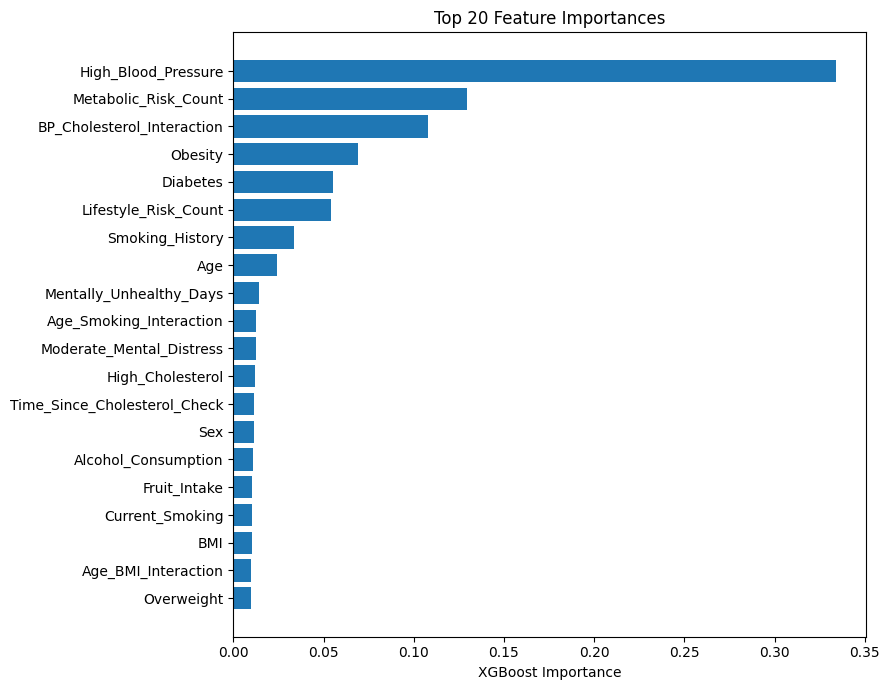

In [ ]:
top20 = importance_df.head(20).sort_values("Importance",ascending=True)
plt.figure(figsize=(9, 7))
plt.barh(top20["Feature"],top20["Importance"])
plt.xlabel("XGBoost Importance")
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
from xgboost import XGBClassifier
feature_selection_results = []
selected_feature_models = {}
feature_counts = [10,15,20,25,30,X_eng_train.shape[1]]
feature_counts = sorted(
    set(
        min(count, X_eng_train.shape[1])
        for count in feature_counts
    )
)
negative_count = (y_eng_train == 0).sum()
positive_count = (y_eng_train == 1).sum()

for feature_count in feature_counts:

    selected_features = importance_df.head(feature_count)["Feature"].tolist()
    model = XGBClassifier(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.85,
        colsample_bytree=0.85,
        gamma=0.2,
        reg_alpha=0.2,
        reg_lambda=3.0,
        scale_pos_weight=negative_count / positive_count,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_eng_train[selected_features],y_eng_train)
    probability = model.predict_proba(X_eng_val[selected_features])[:, 1]

    prediction = (probability >= 0.50).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_eng_val,prediction).ravel()

    feature_selection_results.append({
        "Feature_Count": feature_count,
        "Accuracy": accuracy_score(y_eng_val,prediction),
        "Balanced_Accuracy": balanced_accuracy_score(y_eng_val,prediction),
        "Precision": precision_score(y_eng_val,prediction,zero_division=0),
        "Recall": recall_score(y_eng_val,prediction,zero_division=0),
        "F1": f1_score(y_eng_val,prediction,zero_division=0),
        "ROC_AUC": roc_auc_score(y_eng_val,probability),
        "PR_AUC": average_precision_score(y_eng_val,probability),
        "False_Positive": fp,
        "False_Negative": fn
    })

    selected_feature_models[feature_count] = {
        "model": model,
        "features": selected_features,
        "probability": probability
    }

feature_results_df = pd.DataFrame(feature_selection_results).sort_values(["PR_AUC", "ROC_AUC"],ascending=False)
display(feature_results_df.round(4))

,Feature_Count,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,False_Positive,False_Negative
1,15,0.7898,0.7410,0.0759,0.6898,0.1367,0.8061,0.1284,8367,309
4,27,0.8007,0.7422,0.0790,0.6807,0.1415,0.8084,0.1250,7906,318
2,20,0.7972,0.7423,0.0780,0.6847,0.1401,0.8050,0.1248,8058,314
3,25,0.8006,0.7451,0.0795,0.6867,0.1425,0.8087,0.1234,7918,312
0,10,0.7841,0.7337,0.0731,0.6807,0.1321,0.7960,0.1140,8593,318


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206361 entries, 0 to 206360
Data columns (total 17 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           206361 non-null  float64
 1   Sex                           206361 non-null  int64  
 2   Smoking_History               206361 non-null  float64
 3   Current_Smoking               206361 non-null  float64
 4   Exercise                      206361 non-null  float64
 5   Mentally_Unhealthy_Days       206361 non-null  float64
 6   Fruit_Intake                  206361 non-null  float64
 7   Fruit_Juice_Intake            206361 non-null  float64
 8   Green_Vegetable_Intake        206361 non-null  float64
 9   Other_Vegetable_Intake        206361 non-null  float64
 10  BMI                           206361 non-null  float64
 11  Diabetes                      206361 non-null  float64
 12  High_Blood_Pressure           206361 non-nul

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier
if df_test.isna().sum().sum() != 0:
    raise ValueError(
        "df_clean still contains missing values."
    )

print("Input dataset shape:", df_test.shape)
print("\nTarget distribution:")
print(df_test["Heart_Disease"].value_counts())
print(
    df_test["Heart_Disease"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
# 2. RECREATE IMPORTANT ENGINEERED FEATURES
data = df_test.copy()
data["Overweight"] = (data["BMI"] >= 25).astype(int)
data["Obesity"] = (data["BMI"] >= 30).astype(int)
data["Severe_Obesity"] = (data["BMI"] >= 35).astype(int)
data["Moderate_Mental_Distress"] = (data["Mentally_Unhealthy_Days"] >= 7).astype(int)
data["High_Mental_Distress"] = (data["Mentally_Unhealthy_Days"] >= 14).astype(int)
data["Metabolic_Risk_Count"] = (
    (data["Diabetes"] == 1).astype(int)
    + (data["High_Blood_Pressure"] == 1).astype(int)
    + (data["High_Cholesterol"] == 1).astype(int)
    + data["Obesity"]
)
data["Lifestyle_Risk_Count"] = (
    data["Current_Smoking"].isin([1, 2]).astype(int)
    + (data["Exercise"] == 0).astype(int)
    + data["High_Mental_Distress"]
)

data["Age_BMI_Interaction"] = (data["Age"] * data["BMI"])
data["Age_Smoking_Interaction"] = (data["Age"] * data["Current_Smoking"])
data["BP_Cholesterol_Interaction"] = (
    (data["High_Blood_Pressure"] == 1).astype(int)
    * (data["High_Cholesterol"] == 1).astype(int)
)
data["Diabetes_Obesity_Interaction"] = ((data["Diabetes"] == 1).astype(int)* data["Obesity"])
# 3. FINAL FEATURE SET
final_features = [
    "High_Blood_Pressure",
    "Metabolic_Risk_Count",
    "BP_Cholesterol_Interaction",
    "Obesity",
    "Diabetes",
    "Lifestyle_Risk_Count",
    "Smoking_History",
    "Age",
    "Mentally_Unhealthy_Days",
    "Age_Smoking_Interaction",
    "Moderate_Mental_Distress",
    "High_Cholesterol",
    "Time_Since_Cholesterol_Check",
    "Sex",
    "Alcohol_Consumption",
    "Fruit_Intake",
    "Current_Smoking",
    "BMI",
    "Age_BMI_Interaction",
    "Overweight",
    "Exercise",
    "Other_Vegetable_Intake",
    "Fruit_Juice_Intake",
    "Green_Vegetable_Intake"
]

missing_features = [
    feature
    for feature in final_features
    if feature not in data.columns
]

if missing_features:
    raise ValueError(f"These final features are missing: {missing_features}")

X = data[final_features].copy()
y = data["Heart_Disease"].astype(int).copy()

print("\nFinal feature count:", X.shape[1])
print("Final feature names:")

for number, feature in enumerate(final_features, 1):
    print(number, feature)

# 4. TRAIN / VALIDATION / TEST SPLIT
# 60% TRAIN, 20% VALIDATION, 20% TEST
X_development, X_test, y_development, y_test = (train_test_split(X,y,test_size=0.20,random_state=42,stratify=y))
X_train, X_validation, y_train, y_validation = (
    train_test_split(X_development,y_development,test_size=0.25,random_state=42,stratify=y_development)
)
print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Testing:", X_test.shape)

# 5. MODEL 1:LOGISTIC REGRESSION
logistic_model = Pipeline([("scaler",StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            solver="lbfgs",
            random_state=42
        )
    )
])

logistic_model.fit(X_train,y_train)
logistic_validation_probability = (logistic_model.predict_proba(X_validation)[:, 1])
print("\nLogistic Regression completed.")

# 6. MODEL 2: RANDOM FOREST

random_forest_model = RandomForestClassifier(
    n_estimators=450,
    max_depth=16,
    min_samples_split=20,
    min_samples_leaf=8,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_validation_probability = (
    random_forest_model.predict_proba(
        X_validation
    )[:, 1]
)

print("Random Forest completed.")

# MODEL 3: XGBOOST


negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

scale_positive_weight = (
    negative_count / positive_count
)

xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.025,
    max_depth=4,
    min_child_weight=8,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.15,
    reg_alpha=0.20,
    reg_lambda=3.0,
    scale_pos_weight=scale_positive_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_validation_probability = (
    xgb_model.predict_proba(
        X_validation
    )[:, 1]
)

print("XGBoost completed.")


# AUTOMATIC ENSEMBLE-WEIGHT SELECTION


ensemble_weight_results = []

weight_values = np.arange(
    0.0,
    1.01,
    0.10
)

for logistic_weight in weight_values:
    for rf_weight in weight_values:

        xgb_weight = (
            1.0
            - logistic_weight
            - rf_weight
        )

        if xgb_weight < -1e-9:
            continue

        xgb_weight = max(
            0.0,
            xgb_weight
        )

        validation_probability = (
            logistic_weight
            * logistic_validation_probability
            + rf_weight
            * rf_validation_probability
            + xgb_weight
            * xgb_validation_probability
        )

        ensemble_weight_results.append({
            "Logistic_Weight": logistic_weight,
            "Random_Forest_Weight": rf_weight,
            "XGBoost_Weight": xgb_weight,
            "ROC_AUC": roc_auc_score(
                y_validation,
                validation_probability
            ),
            "PR_AUC": average_precision_score(
                y_validation,
                validation_probability
            )
        })

weight_results_df = pd.DataFrame(
    ensemble_weight_results
)

# PR-AUC receives priority because the positive class is rare.
best_weight_row = (
    weight_results_df
    .sort_values(
        ["PR_AUC", "ROC_AUC"],
        ascending=False
    )
    .iloc[0]
)

logistic_weight = float(
    best_weight_row["Logistic_Weight"]
)

rf_weight = float(
    best_weight_row["Random_Forest_Weight"]
)

xgb_weight = float(
    best_weight_row["XGBoost_Weight"]
)

validation_probability = (
    logistic_weight
    * logistic_validation_probability
    + rf_weight
    * rf_validation_probability
    + xgb_weight
    * xgb_validation_probability
)

print("\nBest ensemble weights:")
print(best_weight_row.round(4))

# 9. VALIDATION THRESHOLD SEARCH

threshold_results = []

for threshold in np.arange(
    0.05,
    0.951,
    0.002
):
    validation_prediction = (
        validation_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        validation_prediction
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_validation,
            validation_prediction
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_validation,
            validation_prediction
        ),
        "Precision": precision_score(
            y_validation,
            validation_prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            validation_prediction,
            zero_division=0
        ),
        "F1": f1_score(
            y_validation,
            validation_prediction,
            zero_division=0
        ),
        "F2": fbeta_score(
            y_validation,
            validation_prediction,
            beta=2,
            zero_division=0
        ),
        "True_Positive": tp,
        "False_Positive": fp,
        "False_Negative": fn,
        "True_Negative": tn
    })

threshold_df = pd.DataFrame(
    threshold_results
)

# 10. SELECT FINAL SCREENING THRESHOLD
# Recall must remain at least 70%.
# Among eligible thresholds, maximize balanced accuracy,
# then F2, then accuracy.


screening_candidates = threshold_df[
    threshold_df["Recall"] >= 0.70
].copy()

if screening_candidates.empty:
    screening_row = threshold_df.loc[
        threshold_df["F2"].idxmax()
    ]
else:
    screening_row = (
        screening_candidates
        .sort_values(
            [
                "Balanced_Accuracy",
                "F2",
                "Accuracy"
            ],
            ascending=False
        )
        .iloc[0]
    )

screening_threshold = float(
    screening_row["Threshold"]
)


# Secondary high-accuracy operating point
accuracy_candidates = threshold_df[
    threshold_df["Recall"] >= 0.35
].copy()

high_accuracy_row = (
    accuracy_candidates
    .sort_values(
        [
            "Accuracy",
            "F1"
        ],
        ascending=False
    )
    .iloc[0]
)

high_accuracy_threshold = float(
    high_accuracy_row["Threshold"]
)


# Maximum-recall operating point with at least 75% accuracy
recall_candidates = threshold_df[
    threshold_df["Accuracy"] >= 0.75
].copy()

maximum_recall_row = (
    recall_candidates
    .sort_values(
        [
            "Recall",
            "Balanced_Accuracy"
        ],
        ascending=False
    )
    .iloc[0]
)

maximum_recall_threshold = float(
    maximum_recall_row["Threshold"]
)

print("\nSelected screening operating point:")
print(screening_row.round(4))

print("\nSecondary high-accuracy operating point:")
print(high_accuracy_row.round(4))

print("\nMaximum-recall point with accuracy >= 75%:")
print(maximum_recall_row.round(4))

# 11. RETRAIN FINAL MODELS USING TRAIN + VALIDATION DATA

final_logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            solver="lbfgs",
            random_state=42
        )
    )
])

final_logistic_model.fit(
    X_development,
    y_development
)

final_random_forest_model = RandomForestClassifier(
    n_estimators=450,
    max_depth=16,
    min_samples_split=20,
    min_samples_leaf=8,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

final_random_forest_model.fit(
    X_development,
    y_development
)

development_negative_count = int(
    (y_development == 0).sum()
)

development_positive_count = int(
    (y_development == 1).sum()
)

final_xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.025,
    max_depth=4,
    min_child_weight=8,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.15,
    reg_alpha=0.20,
    reg_lambda=3.0,
    scale_pos_weight=(
        development_negative_count
        / development_positive_count
    ),
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

final_xgb_model.fit(
    X_development,
    y_development
)

print("\nFinal models retrained using development data.")

# 12. FINAL TEST PROBABILITIES

test_logistic_probability = (
    final_logistic_model.predict_proba(
        X_test
    )[:, 1]
)

test_rf_probability = (
    final_random_forest_model.predict_proba(
        X_test
    )[:, 1]
)

test_xgb_probability = (
    final_xgb_model.predict_proba(
        X_test
    )[:, 1]
)

test_probability = (
    logistic_weight
    * test_logistic_probability
    + rf_weight
    * test_rf_probability
    + xgb_weight
    * test_xgb_probability
)

# 13. FINAL TEST EVALUATION FUNCTION
def evaluate_test_threshold(
    name,
    threshold
):
    prediction = (
        test_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        prediction
    ).ravel()

    result = {
        "Operating_Point": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_test,
            prediction
        ),
        "Precision": precision_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "F2": fbeta_score(
            y_test,
            prediction,
            beta=2,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            test_probability
        ),
        "PR_AUC": average_precision_score(
            y_test,
            test_probability
        ),
        "True_Positive": tp,
        "False_Positive": fp,
        "False_Negative": fn,
        "True_Negative": tn
    }

    return result, prediction


screening_result, screening_prediction = (
    evaluate_test_threshold(
        "Screening",
        screening_threshold
    )
)

accuracy_result, accuracy_prediction = (
    evaluate_test_threshold(
        "High Accuracy",
        high_accuracy_threshold
    )
)

recall_result, recall_prediction = (
    evaluate_test_threshold(
        "Higher Recall",
        maximum_recall_threshold
    )
)

final_results = pd.DataFrame([
    screening_result,
    accuracy_result,
    recall_result
])

print("\n" + "=" * 75)
print("FINAL UNTOUCHED TEST RESULTS")
print("=" * 75)

display(
    final_results.round(4)
)


# ------------------------------------------------------------
# 14. MAIN SCREENING MODEL REPORT
# ------------------------------------------------------------

print("\nMAIN SCREENING MODEL")
print("-" * 50)

print(
    classification_report(
        y_test,
        screening_prediction,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ],
        digits=4
    )
)

print("Confusion matrix:")
print(confusion_matrix(y_test,screening_prediction))

# 15. SAVE FINAL OUTPUTS


import joblib
import json

joblib.dump(final_logistic_model,"final_logistic_model.pkl")
joblib.dump(final_random_forest_model,"final_random_forest_model.pkl")
joblib.dump(final_xgb_model,"final_xgboost_model.pkl")

final_configuration = {
    "features": final_features,
    "ensemble_weights": {
        "logistic_regression": logistic_weight,
        "random_forest": rf_weight,
        "xgboost": xgb_weight
    },
    "thresholds": {
        "screening": screening_threshold,
        "high_accuracy": high_accuracy_threshold,
        "higher_recall": maximum_recall_threshold
    },
    "sleep_limitation": (
        "Sleep was unavailable in the selected "
        "BRFSS 2021 analytical file."
    )
}

with open(
    "final_model_configuration.json",
    "w"
) as configuration_file:
    json.dump(final_configuration,configuration_file,indent=4)

final_results.to_csv("final_test_results.csv",index=False)

print("\nFiles saved:")
print("1. final_logistic_model.pkl")
print("2. final_random_forest_model.pkl")
print("3. final_xgboost_model.pkl")
print("4. final_model_configuration.json")
print("5. final_test_results.csv")

Input dataset shape: (206361, 17)

Target distribution:
Heart_Disease
0    201382
1      4979
Name: count, dtype: int64
Heart_Disease
0    97.59
1     2.41
Name: proportion, dtype: float64

Final feature count: 24
Final feature names:
1 High_Blood_Pressure
2 Metabolic_Risk_Count
3 BP_Cholesterol_Interaction
4 Obesity
5 Diabetes
6 Lifestyle_Risk_Count
7 Smoking_History
8 Age
9 Mentally_Unhealthy_Days
10 Age_Smoking_Interaction
11 Moderate_Mental_Distress
12 High_Cholesterol
13 Time_Since_Cholesterol_Check
14 Sex
15 Alcohol_Consumption
16 Fruit_Intake
17 Current_Smoking
18 BMI
19 Age_BMI_Interaction
20 Overweight
21 Exercise
22 Other_Vegetable_Intake
23 Fruit_Juice_Intake
24 Green_Vegetable_Intake
Training: (123816, 24)
Validation: (41272, 24)
Testing: (41273, 24)

Logistic Regression completed.
Random Forest completed.
XGBoost completed.

Best ensemble weights:
Logistic_Weight         0.4000
Random_Forest_Weight    0.1000
XGBoost_Weight          0.5000
ROC_AUC                 0.8123
PR_

,Operating_Point,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC,True_Positive,False_Positive,False_Negative,True_Negative
0,Screening,0.430,0.7580,0.7487,0.0703,0.7390,0.1285,0.2547,0.8213,0.1354,736,9727,260,30550
1,High Accuracy,0.746,0.9317,0.6610,0.1459,0.3765,0.2103,0.2860,0.8213,0.1354,375,2196,621,38081
2,Higher Recall,0.418,0.7486,0.7503,0.0689,0.7520,0.1262,0.2520,0.8213,0.1354,749,10128,247,30149



MAIN SCREENING MODEL
--------------------------------------------------
                  precision    recall  f1-score   support

No Heart Disease     0.9916    0.7585    0.8595     40277
   Heart Disease     0.0703    0.7390    0.1285       996

        accuracy                         0.7580     41273
       macro avg     0.5310    0.7487    0.4940     41273
    weighted avg     0.9693    0.7580    0.8419     41273

Confusion matrix:
[[30550  9727]
 [  260   736]]

Files saved:
1. final_logistic_model.pkl
2. final_random_forest_model.pkl
3. final_xgboost_model.pkl
4. final_model_configuration.json
5. final_test_results.csv


In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
#Step 2: Create the SHAP explainer
# Use a sample instead of all 41,273 test records because full SHAP computation and plotting may consume unnecessary memory.
# Select a representative test sample
shap_sample_size = min(5000, len(X_test))

X_shap = X_test.sample(
    n=shap_sample_size,
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (5000, 24)


In [ ]:
explainer = shap.TreeExplainer(final_xgb_model)
shap_values = explainer(X_shap)

print("SHAP values calculated.")
print("SHAP shape:", shap_values.values.shape)

SHAP values calculated.
SHAP shape: (5000, 24)


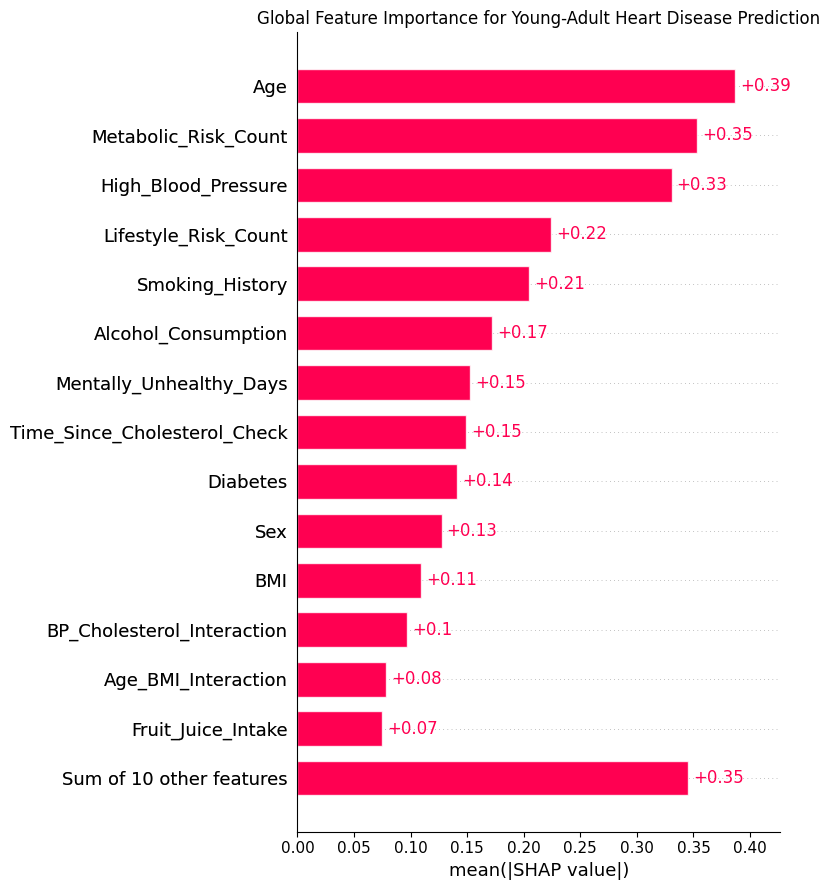

In [ ]:
#Step 3: Global SHAP importance bar chart
shap.plots.bar(shap_values,max_display=15,show=False)

plt.title("Global Feature Importance for Young-Adult Heart Disease Prediction")
plt.tight_layout()
plt.savefig("shap_global_importance.png",dpi=300,bbox_inches="tight")

plt.show()

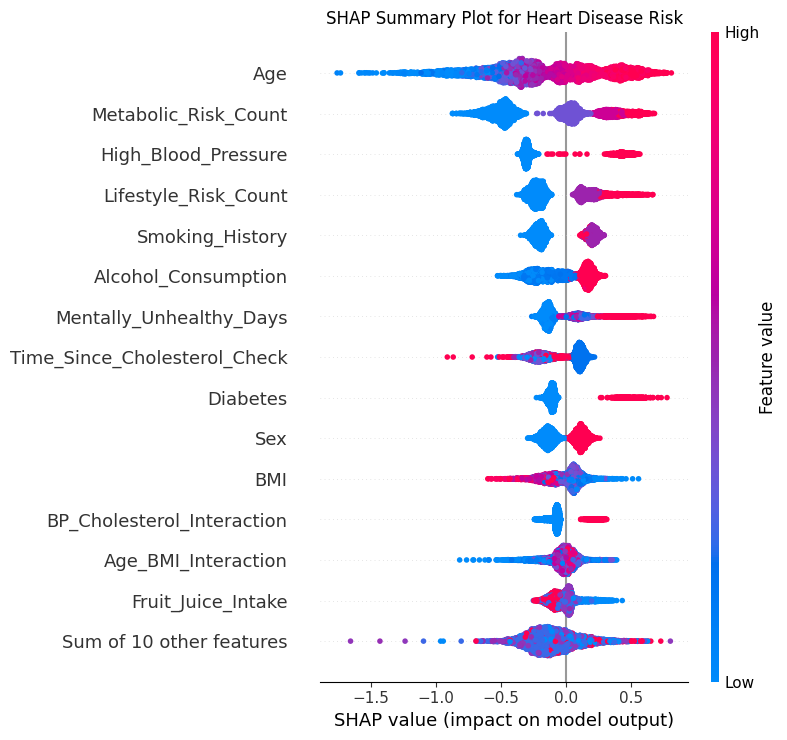

In [ ]:
#Step 4: SHAP beeswarm plot:most important explainability graph.
shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Plot for Heart Disease Risk"
)

plt.tight_layout()

plt.savefig(
    "shap_summary_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Step 5: Produce a numeric SHAP ranking
mean_absolute_shap = np.abs(
    shap_values.values
).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": mean_absolute_shap
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

display(shap_importance_df)

shap_importance_df.to_csv(
    "shap_feature_importance.csv",
    index=False
)

,Feature,Mean_Absolute_SHAP
0,Age,0.386840
1,Metabolic_Risk_Count,0.353145
2,High_Blood_Pressure,0.330672
3,Lifestyle_Risk_Count,0.224201
4,Smoking_History,0.205011
5,Alcohol_Consumption,0.172303
6,Mentally_Unhealthy_Days,0.152651
7,Time_Since_Cholesterol_Check,0.148886
8,Diabetes,0.140725
9,Sex,0.127321


In [ ]:
#Step 6: Explain a true-positive patient
screening_positive_indices = X_test.index[
    (y_test == 1) &
    (screening_prediction == 1)
]

print(
    "Available true-positive cases:",
    len(screening_positive_indices)
)

Available true-positive cases: 736


In [ ]:
#selecting one
true_positive_index = screening_positive_indices[0]
patient_data = X_test.loc[[true_positive_index]]

print("Selected patient index:", true_positive_index)
display(patient_data)

Selected patient index: 190339


,High_Blood_Pressure,Metabolic_Risk_Count,BP_Cholesterol_Interaction,Obesity,Diabetes,Lifestyle_Risk_Count,Smoking_History,Age,Mentally_Unhealthy_Days,Age_Smoking_Interaction,...,Alcohol_Consumption,Fruit_Intake,Current_Smoking,BMI,Age_BMI_Interaction,Overweight,Exercise,Other_Vegetable_Intake,Fruit_Juice_Intake,Green_Vegetable_Intake
190339,1.0,3,0,1,1.0,1,1.0,52.0,30.0,0.0,...,220.0,204.0,0.0,33.52,1743.04,1,1.0,101.0,555.0,304.0


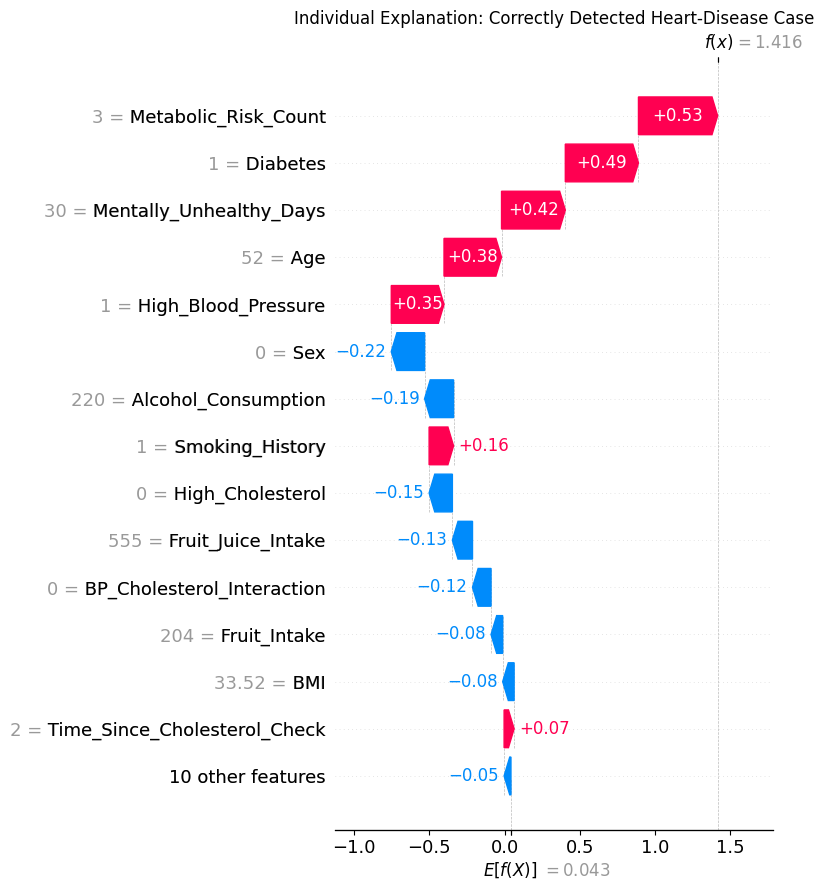

In [ ]:
#Calculate SHAP values using the XGBoost component:
patient_shap = explainer(patient_data)
shap.plots.waterfall(patient_shap[0],max_display=15,show=False)

plt.title("Individual Explanation: Correctly Detected Heart-Disease Case")
plt.tight_layout()

plt.savefig("shap_true_positive_patient.png",dpi=300,bbox_inches="tight")
plt.show()

In [ ]:
#Step 7: Show the ensemble probability for that patient
patient_logistic_probability = (
    final_logistic_model.predict_proba(
        patient_data
    )[0, 1]
)

patient_rf_probability = (
    final_random_forest_model.predict_proba(
        patient_data
    )[0, 1]
)

patient_xgb_probability = (
    final_xgb_model.predict_proba(
        patient_data
    )[0, 1]
)

patient_ensemble_probability = (
    logistic_weight * patient_logistic_probability
    + rf_weight * patient_rf_probability
    + xgb_weight * patient_xgb_probability
)

print(
    "Logistic probability:",
    round(patient_logistic_probability, 4)
)

print(
    "Random Forest probability:",
    round(patient_rf_probability, 4)
)

print(
    "XGBoost probability:",
    round(patient_xgb_probability, 4)
)

print(
    "Final ensemble probability:",
    round(patient_ensemble_probability, 4)
)

print(
    "Screening threshold:",
    round(screening_threshold, 4)
)

Logistic probability: 0.8551
Random Forest probability: 0.582
XGBoost probability: 0.8048
Final ensemble probability: 0.8026
Screening threshold: 0.43


In [ ]:
#Step 8: Extract the top contributing factors numerically
def get_patient_shap_factors(
    patient_row,
    patient_explanation,
    top_n=10
):
    result = pd.DataFrame({
        "Feature": patient_row.columns,
        "Feature_Value": patient_row.iloc[0].values,
        "SHAP_Value": patient_explanation.values[0]
    })

    result["Absolute_SHAP"] = (
        result["SHAP_Value"].abs()
    )

    result["Effect"] = np.where(
        result["SHAP_Value"] > 0,
        "Increased predicted risk",
        "Decreased predicted risk"
    )

    return result.sort_values(
        "Absolute_SHAP",
        ascending=False
    ).head(top_n)

In [ ]:
patient_factor_table = get_patient_shap_factors(
    patient_data,
    patient_shap,
    top_n=10
)

display(patient_factor_table)

patient_factor_table.to_csv(
    "individual_patient_shap_factors.csv",
    index=False
)

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP,Effect
1,Metabolic_Risk_Count,3.0,0.526244,0.526244,Increased predicted risk
4,Diabetes,1.0,0.486088,0.486088,Increased predicted risk
8,Mentally_Unhealthy_Days,30.0,0.423783,0.423783,Increased predicted risk
7,Age,52.0,0.382279,0.382279,Increased predicted risk
0,High_Blood_Pressure,1.0,0.350417,0.350417,Increased predicted risk
13,Sex,0.0,-0.221399,0.221399,Decreased predicted risk
14,Alcohol_Consumption,220.0,-0.192486,0.192486,Decreased predicted risk
6,Smoking_History,1.0,0.162539,0.162539,Increased predicted risk
11,High_Cholesterol,0.0,-0.154653,0.154653,Decreased predicted risk
22,Fruit_Juice_Intake,555.0,-0.133718,0.133718,Decreased predicted risk


In [ ]:
#Step 9: Create a reusable explanation function
def explain_patient_by_index(
    patient_index,
    max_display=12
):
    if patient_index not in X_test.index:
        raise ValueError(
            "Patient index is not present in X_test."
        )

    patient = X_test.loc[[patient_index]]

    logistic_probability = (
        final_logistic_model.predict_proba(
            patient
        )[0, 1]
    )

    rf_probability = (
        final_random_forest_model.predict_proba(
            patient
        )[0, 1]
    )

    xgb_probability = (
        final_xgb_model.predict_proba(
            patient
        )[0, 1]
    )

    ensemble_probability = (
        logistic_weight * logistic_probability
        + rf_weight * rf_probability
        + xgb_weight * xgb_probability
    )

    if ensemble_probability >= high_accuracy_threshold:
        risk_level = "High predicted risk"
    elif ensemble_probability >= screening_threshold:
        risk_level = "Elevated predicted risk"
    else:
        risk_level = "Lower predicted risk"

    patient_explanation = explainer(
        patient
    )

    factor_table = get_patient_shap_factors(
        patient,
        patient_explanation,
        top_n=max_display
    )

    print("Patient index:", patient_index)
    print(
        "Actual outcome:",
        int(y_test.loc[patient_index])
    )
    print(
        "Ensemble probability:",
        round(ensemble_probability, 4)
    )
    print("Risk category:", risk_level)

    display(factor_table)

    shap.plots.waterfall(
        patient_explanation[0],
        max_display=max_display
    )

    return {
        "patient_index": patient_index,
        "actual_outcome": int(
            y_test.loc[patient_index]
        ),
        "ensemble_probability": float(
            ensemble_probability
        ),
        "risk_category": risk_level,
        "factor_table": factor_table
    }

Patient index: 190339
Actual outcome: 1
Ensemble probability: 0.8026
Risk category: High predicted risk


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP,Effect
1,Metabolic_Risk_Count,3.0,0.526244,0.526244,Increased predicted risk
4,Diabetes,1.0,0.486088,0.486088,Increased predicted risk
8,Mentally_Unhealthy_Days,30.0,0.423783,0.423783,Increased predicted risk
7,Age,52.0,0.382279,0.382279,Increased predicted risk
0,High_Blood_Pressure,1.0,0.350417,0.350417,Increased predicted risk
13,Sex,0.0,-0.221399,0.221399,Decreased predicted risk
14,Alcohol_Consumption,220.0,-0.192486,0.192486,Decreased predicted risk
6,Smoking_History,1.0,0.162539,0.162539,Increased predicted risk
11,High_Cholesterol,0.0,-0.154653,0.154653,Decreased predicted risk
22,Fruit_Juice_Intake,555.0,-0.133718,0.133718,Decreased predicted risk


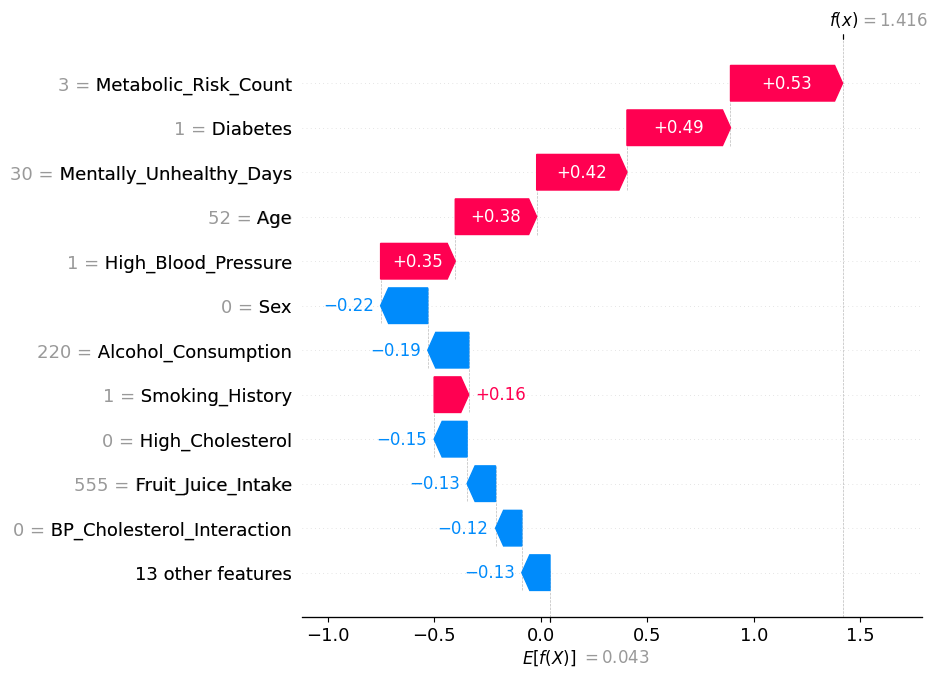

In [ ]:
patient_result = explain_patient_by_index(
    true_positive_index
)

In [ ]:
#Step 10: Explain a false-negative case
false_negative_indices = X_test.index[
    (y_test == 1) &
    (screening_prediction == 0)
]

print(
    "Available false-negative cases:",
    len(false_negative_indices)
)

Available false-negative cases: 260


Patient index: 121116
Actual outcome: 1
Ensemble probability: 0.3892
Risk category: Lower predicted risk


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP,Effect
7,Age,53.0,0.529693,0.529693,Increased predicted risk
14,Alcohol_Consumption,204.0,-0.318264,0.318264,Decreased predicted risk
13,Sex,0.0,-0.263145,0.263145,Decreased predicted risk
0,High_Blood_Pressure,0.0,-0.255962,0.255962,Decreased predicted risk
5,Lifestyle_Risk_Count,0.0,-0.232489,0.232489,Decreased predicted risk
6,Smoking_History,1.0,0.219096,0.219096,Increased predicted risk
1,Metabolic_Risk_Count,1.0,0.160673,0.160673,Increased predicted risk
22,Fruit_Juice_Intake,555.0,-0.142137,0.142137,Decreased predicted risk
8,Mentally_Unhealthy_Days,0.0,-0.132788,0.132788,Decreased predicted risk
12,Time_Since_Cholesterol_Check,2.0,0.111248,0.111248,Increased predicted risk


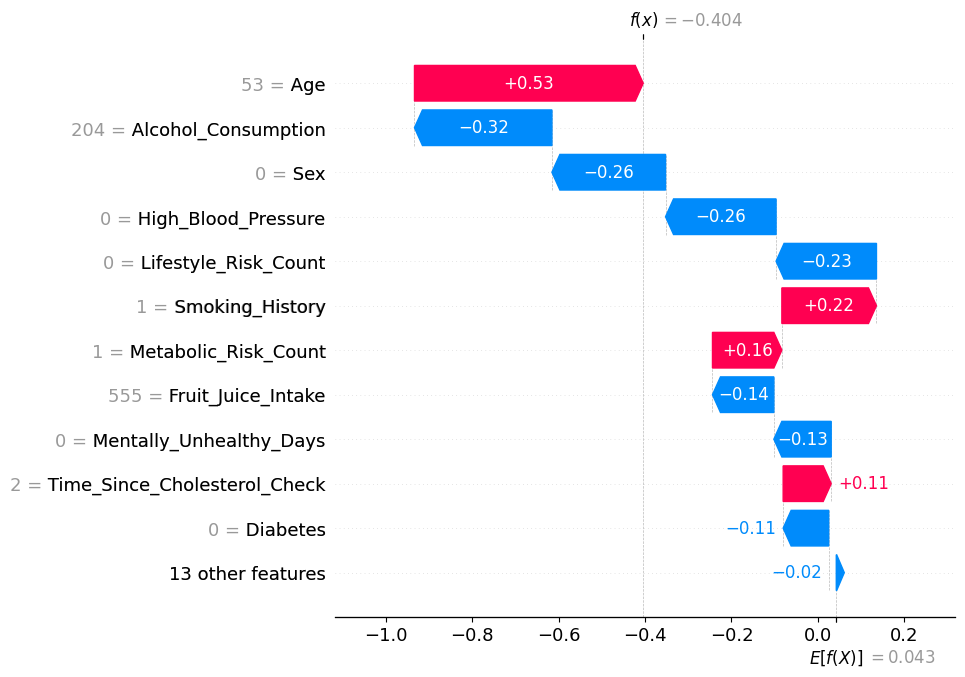

In [ ]:
if len(false_negative_indices) > 0:
    false_negative_index = (
        false_negative_indices[0]
    )

    false_negative_result = (
        explain_patient_by_index(
            false_negative_index
        )
    )

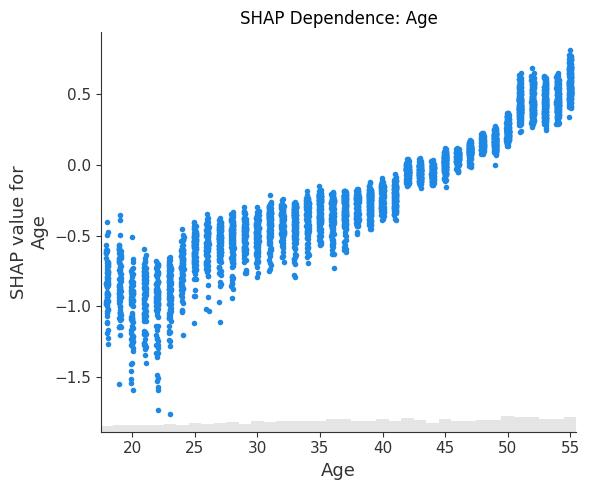

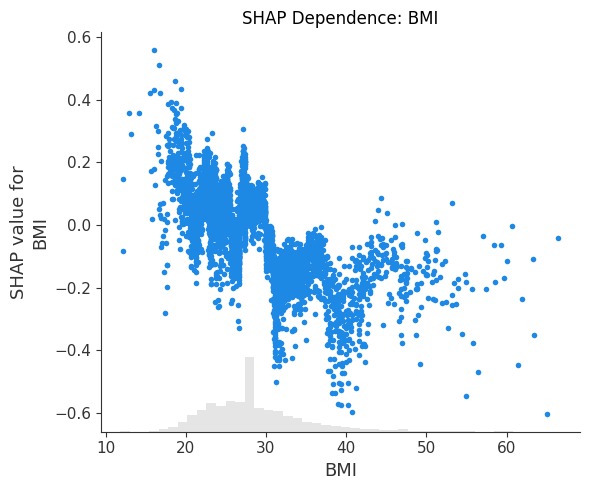

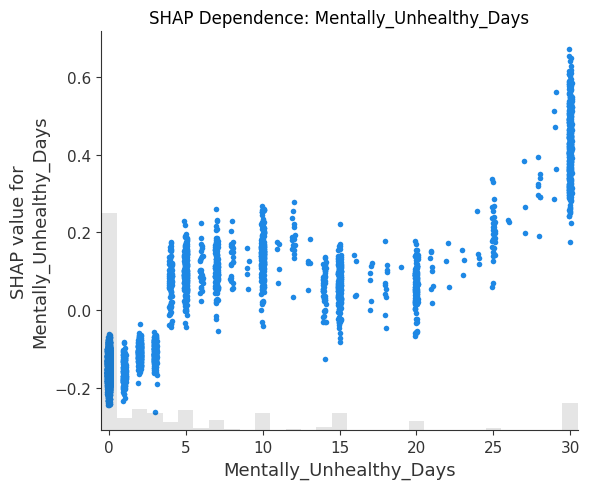

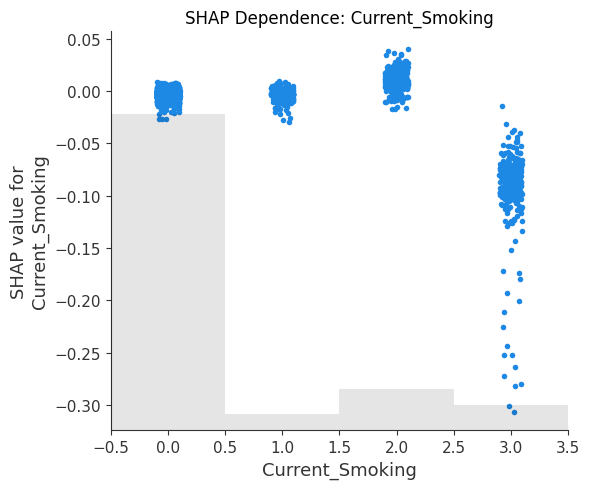

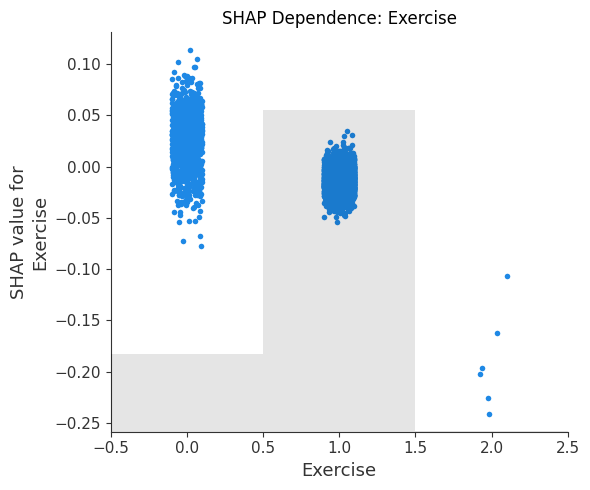

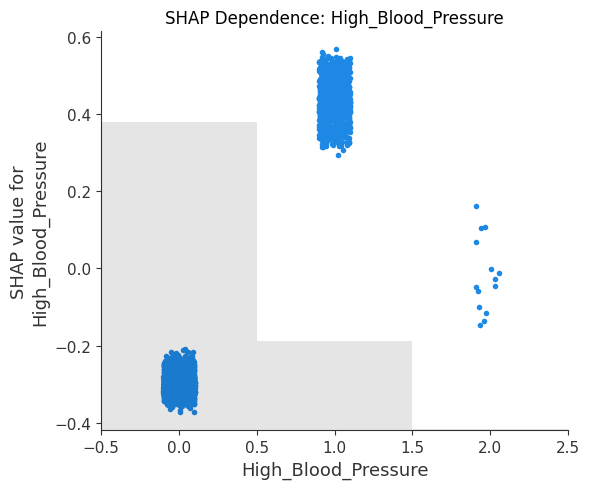

In [ ]:
#Step 11: SHAP dependence plots
#Generate plots for important clinical and lifestyle factors.
important_dependence_features = [
    "Age",
    "BMI",
    "Mentally_Unhealthy_Days",
    "Current_Smoking",
    "Exercise",
    "High_Blood_Pressure"
]

for feature in important_dependence_features:

    if feature not in X_shap.columns:
        continue

    shap.plots.scatter(
        shap_values[:, feature],
        show=False
    )

    plt.title(
        f"SHAP Dependence: {feature}"
    )

    plt.tight_layout()

    safe_name = feature.lower().replace(
        " ",
        "_"
    )

    plt.savefig(
        f"shap_dependence_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
import joblib

joblib.dump(
    explainer,
    "final_xgboost_shap_explainer.pkl"
)

print("SHAP explainer saved.")

SHAP explainer saved.


In [ ]:
#final prediction function
import numpy as np
import pandas as pd
import shap

def predict_and_explain_heart_risk(
    patient_values,
    top_n=10
):
    """
    Predict and explain heart-disease risk for one respondent.

    patient_values:
        Dictionary containing values for all final_features.
    """

    # ---------------------------------------------------------
    # 1. Create patient DataFrame in correct feature order
    # ---------------------------------------------------------
    patient_df = pd.DataFrame(
        [patient_values]
    )

    missing_inputs = [
        feature
        for feature in final_features
        if feature not in patient_df.columns
    ]

    if missing_inputs:
        raise ValueError(
            f"Missing patient features: {missing_inputs}"
        )

    patient_df = patient_df[final_features].copy()

    # ---------------------------------------------------------
    # 2. Model probabilities
    # ---------------------------------------------------------
    logistic_probability = (
        final_logistic_model.predict_proba(
            patient_df
        )[0, 1]
    )

    random_forest_probability = (
        final_random_forest_model.predict_proba(
            patient_df
        )[0, 1]
    )

    xgboost_probability = (
        final_xgb_model.predict_proba(
            patient_df
        )[0, 1]
    )

    ensemble_probability = (
        logistic_weight * logistic_probability
        + rf_weight * random_forest_probability
        + xgb_weight * xgboost_probability
    )

    # ---------------------------------------------------------
    # 3. Risk category
    # ---------------------------------------------------------
    if ensemble_probability >= high_accuracy_threshold:
        risk_category = "High predicted risk"

    elif ensemble_probability >= screening_threshold:
        risk_category = "Elevated predicted risk"

    else:
        risk_category = "Lower predicted risk"

    screening_prediction = int(
        ensemble_probability >= screening_threshold
    )

    # ---------------------------------------------------------
    # 4. SHAP explanation using XGBoost component
    # ---------------------------------------------------------
    patient_shap = explainer(
        patient_df
    )

    explanation_df = pd.DataFrame({
        "Feature": final_features,
        "Patient_Value": patient_df.iloc[0].values,
        "SHAP_Value": patient_shap.values[0]
    })

    explanation_df["Absolute_SHAP"] = (
        explanation_df["SHAP_Value"].abs()
    )

    explanation_df["Contribution"] = np.where(
        explanation_df["SHAP_Value"] > 0,
        "Increased predicted risk",
        "Decreased predicted risk"
    )

    explanation_df = explanation_df.sort_values(
        "Absolute_SHAP",
        ascending=False
    ).head(top_n)

    # ---------------------------------------------------------
    # 5. Display final result
    # ---------------------------------------------------------
    print("=" * 65)
    print("YOUNG-ADULT HEART-DISEASE RISK ASSESSMENT")
    print("=" * 65)

    print(
        f"Logistic Regression probability: "
        f"{logistic_probability:.4f}"
    )

    print(
        f"Random Forest probability: "
        f"{random_forest_probability:.4f}"
    )

    print(
        f"XGBoost probability: "
        f"{xgboost_probability:.4f}"
    )

    print(
        f"\nFinal ensemble probability: "
        f"{ensemble_probability:.4f}"
    )

    print(
        f"Screening prediction: "
        f"{'Positive risk flag' if screening_prediction == 1 else 'Negative risk flag'}"
    )

    print(
        f"Risk category: {risk_category}"
    )

    print(
        f"Screening threshold: "
        f"{screening_threshold:.4f}"
    )

    print(
        f"High-risk threshold: "
        f"{high_accuracy_threshold:.4f}"
    )

    print("\nTop prediction contributors:")
    display(
        explanation_df[
            [
                "Feature",
                "Patient_Value",
                "SHAP_Value",
                "Contribution"
            ]
        ]
    )

    shap.plots.waterfall(
        patient_shap[0],
        max_display=top_n
    )

    return {
        "ensemble_probability": float(
            ensemble_probability
        ),
        "risk_category": risk_category,
        "screening_prediction": screening_prediction,
        "logistic_probability": float(
            logistic_probability
        ),
        "random_forest_probability": float(
            random_forest_probability
        ),
        "xgboost_probability": float(
            xgboost_probability
        ),
        "explanation": explanation_df
    }

YOUNG-ADULT HEART-DISEASE RISK ASSESSMENT
Logistic Regression probability: 0.0984
Random Forest probability: 0.0575
XGBoost probability: 0.1600

Final ensemble probability: 0.1251
Screening prediction: Negative risk flag
Risk category: Lower predicted risk
Screening threshold: 0.4300
High-risk threshold: 0.7460

Top prediction contributors:


,Feature,Patient_Value,SHAP_Value,Contribution
1,Metabolic_Risk_Count,0.00,-0.457026,Decreased predicted risk
7,Age,28.00,-0.379150,Decreased predicted risk
0,High_Blood_Pressure,0.00,-0.296545,Decreased predicted risk
12,Time_Since_Cholesterol_Check,5.00,-0.236402,Decreased predicted risk
5,Lifestyle_Risk_Count,0.00,-0.212635,Decreased predicted risk
6,Smoking_History,0.00,-0.197771,Decreased predicted risk
21,Other_Vegetable_Intake,303.00,0.148262,Increased predicted risk
8,Mentally_Unhealthy_Days,0.00,-0.123971,Decreased predicted risk
17,BMI,28.21,0.110842,Increased predicted risk
4,Diabetes,0.00,-0.090759,Decreased predicted risk


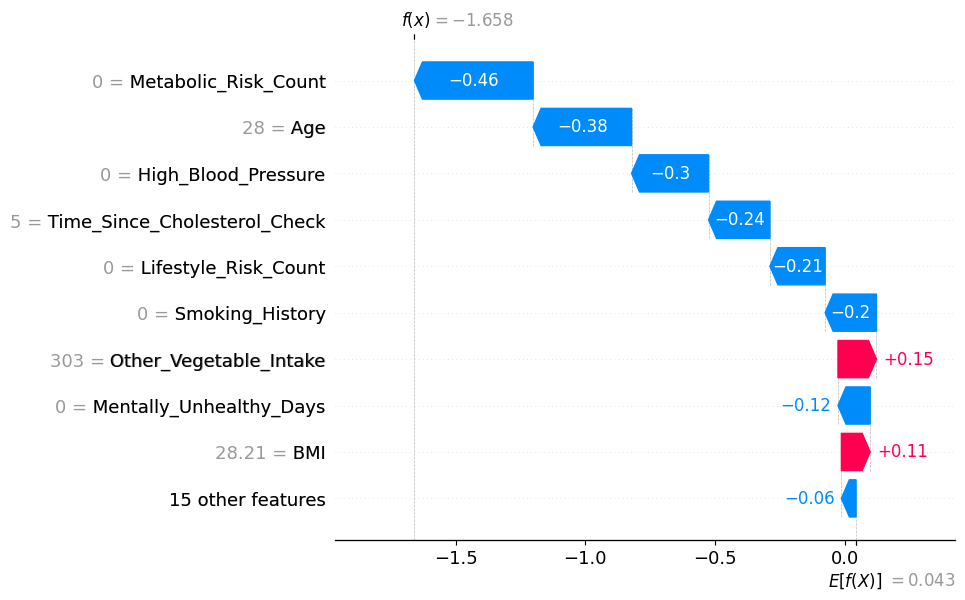


Actual recorded outcome: 0


In [ ]:
#test it with an actual test repondant
sample_index = X_test.index[0]
sample_patient = (X_test.loc[sample_index].to_dict())

final_patient_result = (predict_and_explain_heart_risk(sample_patient,top_n=10))
print(
    "\nActual recorded outcome:",
    int(y_test.loc[sample_index])
)

YOUNG-ADULT HEART-DISEASE RISK ASSESSMENT
Logistic Regression probability: 0.8551
Random Forest probability: 0.5820
XGBoost probability: 0.8048

Final ensemble probability: 0.8026
Screening prediction: Positive risk flag
Risk category: High predicted risk
Screening threshold: 0.4300
High-risk threshold: 0.7460

Top prediction contributors:


,Feature,Patient_Value,SHAP_Value,Contribution
1,Metabolic_Risk_Count,3.0,0.526244,Increased predicted risk
4,Diabetes,1.0,0.486088,Increased predicted risk
8,Mentally_Unhealthy_Days,30.0,0.423783,Increased predicted risk
7,Age,52.0,0.382279,Increased predicted risk
0,High_Blood_Pressure,1.0,0.350417,Increased predicted risk
13,Sex,0.0,-0.221399,Decreased predicted risk
14,Alcohol_Consumption,220.0,-0.192486,Decreased predicted risk
6,Smoking_History,1.0,0.162539,Increased predicted risk
11,High_Cholesterol,0.0,-0.154653,Decreased predicted risk
22,Fruit_Juice_Intake,555.0,-0.133718,Decreased predicted risk


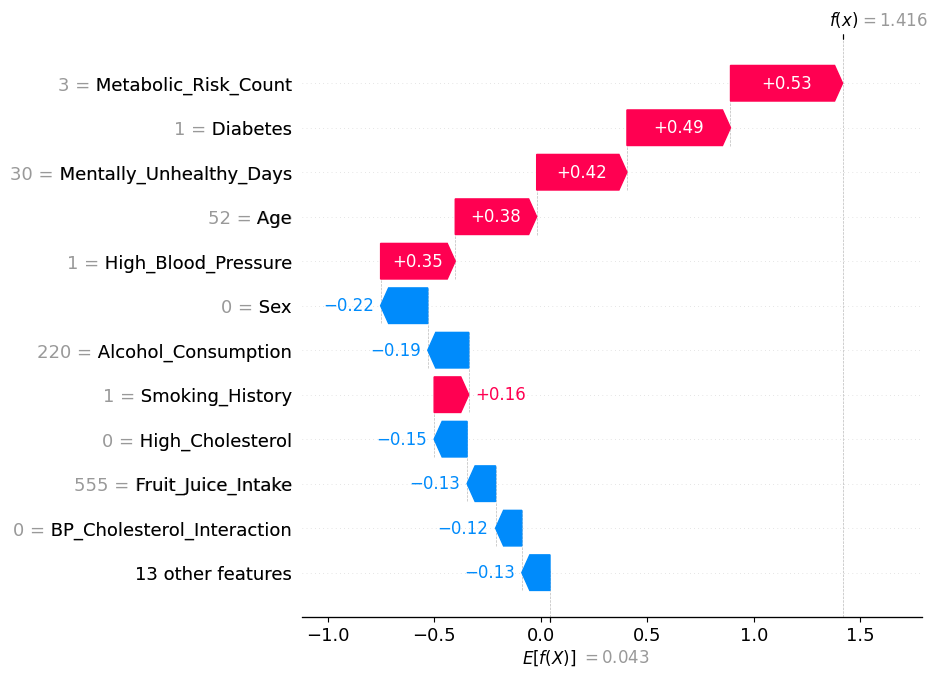


Actual recorded outcome: 1


In [ ]:
#Test a correctly detected positive case
true_positive_indices = X_test.index[
    (y_test == 1) &
    (screening_prediction == 1)
]

positive_index = true_positive_indices[0]

positive_patient = (
    X_test.loc[positive_index]
    .to_dict()
)

positive_result = (
    predict_and_explain_heart_risk(
        positive_patient,
        top_n=12
    )
)

print(
    "\nActual recorded outcome:",
    int(y_test.loc[positive_index])
)

In [ ]:
import json

with open(
    "final_feature_names.json",
    "w"
) as file:
    json.dump(
        final_features,
        file,
        indent=4
    )

print("Final feature names saved.")

Final feature names saved.


In [ ]:
shap_importance_df.to_csv(
    "final_shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved.")

SHAP feature importance saved.


In [ ]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.1/259.1 kB 24.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.56.3 which is incompatible.


In [ ]:
import os
from google.colab import userdata

# Safely fetches the key you just saved in the sidebar
os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")

print("API Key loaded successfully!")

API Key loaded successfully!


In [ ]:
from google import genai

gemini_client = genai.Client()

In [ ]:
import numpy as np
import pandas as pd


FEATURE_DISPLAY_NAMES = {
    "Metabolic_Risk_Count": "Metabolic risk count",
    "Lifestyle_Risk_Count": "Lifestyle risk count",
    "Mentally_Unhealthy_Days": "Mentally unhealthy days",
    "High_Blood_Pressure": "High blood pressure",
    "High_Cholesterol": "High cholesterol",
    "Smoking_History": "Smoking history",
    "Current_Smoking": "Current smoking",
    "Alcohol_Consumption": "Alcohol consumption",
    "Fruit_Intake": "Fruit intake",
    "Fruit_Juice_Intake": "Fruit juice intake",
    "Other_Vegetable_Intake": "Other vegetable intake",
    "Green_Vegetable_Intake": "Green vegetable intake",
    "BP_Cholesterol_Interaction": (
        "Blood pressure–cholesterol interaction"
    ),
    "Age_BMI_Interaction": "Age–BMI interaction",
    "Time_Since_Cholesterol_Check": (
        "Time since cholesterol check"
    )
}


BINARY_VALUE_LABELS = {
    "Diabetes": {
        0: "No",
        1: "Yes"
    },
    "High_Blood_Pressure": {
        0: "No",
        1: "Yes",
        2: "Unknown"
    },
    "High_Cholesterol": {
        0: "No",
        1: "Yes",
        2: "Unknown"
    },
    "Smoking_History": {
        0: "No",
        1: "Yes"
    },
    "Current_Smoking": {
        0: "No",
        1: "Yes"
    },
    "Exercise": {
        0: "No",
        1: "Yes"
    },
    "Obesity": {
        0: "No",
        1: "Yes"
    },
    "Overweight": {
        0: "No",
        1: "Yes"
    },
    "Sex": {
        0: "Female",
        1: "Male"
    }
}


SURVEY_CODE_FEATURES = {
    "Alcohol_Consumption",
    "Fruit_Intake",
    "Fruit_Juice_Intake",
    "Other_Vegetable_Intake",
    "Green_Vegetable_Intake",
    "Time_Since_Cholesterol_Check"
}


def get_display_name(feature):
    return FEATURE_DISPLAY_NAMES.get(
        feature,
        feature.replace("_", " ")
    )


def get_readable_value(feature, value):
    """
    Convert model values into human-readable display values.

    Raw survey-frequency codes are not interpreted medically
    unless their exact codebook conversion has been implemented.
    """

    if pd.isna(value):
        return "Unknown"

    # Binary and categorical variables
    if feature in BINARY_VALUE_LABELS:
        try:
            numeric_value = int(value)

            return BINARY_VALUE_LABELS[feature].get(
                numeric_value,
                f"Encoded category {numeric_value}"
            )

        except (TypeError, ValueError):
            return str(value)

    # Avoid showing encoded survey values as real quantities
    if feature in SURVEY_CODE_FEATURES:
        try:
            numeric_value = int(value)

            if numeric_value == 555:
                return "Never"

            if numeric_value in [777, 999]:
                return "Unknown or not reported"

            return f"Survey response code {numeric_value}"

        except (TypeError, ValueError):
            return str(value)

    # Integer counts
    if feature in {
        "Age",
        "Metabolic_Risk_Count",
        "Lifestyle_Risk_Count",
        "Mentally_Unhealthy_Days"
    }:
        return str(int(round(float(value))))

    # Continuous values
    try:
        return str(round(float(value), 2))

    except (TypeError, ValueError):
        return str(value)

In [ ]:
def build_shap_evidence(
    patient_df,
    patient_shap,
    ensemble_probability,
    screening_threshold,
    high_specificity_threshold,
    top_n=10
):
    """
    Create structured and human-readable evidence from
    one patient's SHAP explanation.
    """

    shap_values = patient_shap.values

    # Handle different SHAP output shapes
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    patient_values = shap_values[0]

    explanation_df = pd.DataFrame({
        "feature": patient_df.columns,
        "value": patient_df.iloc[0].values,
        "shap_value": patient_values
    })

    explanation_df["absolute_shap"] = (
        explanation_df["shap_value"].abs()
    )

    explanation_df["direction"] = np.where(
        explanation_df["shap_value"] > 0,
        "increases predicted risk",
        np.where(
            explanation_df["shap_value"] < 0,
            "decreases predicted risk",
            "has almost no effect"
        )
    )

    explanation_df = explanation_df.sort_values(
        "absolute_shap",
        ascending=False
    ).head(top_n)

    # Risk category
    if ensemble_probability >= high_specificity_threshold:
        risk_category = "high predicted risk"

    elif ensemble_probability >= screening_threshold:
        risk_category = "elevated predicted risk"

    else:
        risk_category = "lower predicted risk"

    contributors = []

    for _, row in explanation_df.iterrows():
        feature = str(row["feature"])
        shap_value = float(row["shap_value"])

        contributors.append({
            "feature_name": get_display_name(feature),
            "model_feature": feature,
            "recorded_value": get_readable_value(
                feature,
                row["value"]
            ),
            "shap_value": round(shap_value, 4),
            "effect": (
                "increased the model prediction"
                if shap_value > 0
                else "decreased the model prediction"
                if shap_value < 0
                else "had almost no effect"
            )
        })

    evidence = {
        "predicted_probability_percent": round(
            float(ensemble_probability) * 100,
            1
        ),
        "predicted_probability": round(
            float(ensemble_probability),
            4
        ),
        "risk_category": risk_category,
        "screening_threshold_percent": round(
            float(screening_threshold) * 100,
            1
        ),
        "high_specificity_threshold_percent": round(
            float(high_specificity_threshold) * 100,
            1
        ),
        "top_contributors": contributors,
        "study_population": {
            "minimum_age": 18,
            "maximum_age": 55
        }
    }

    # Add readable columns for notebook display
    explanation_df["display_feature"] = (
        explanation_df["feature"].apply(
            get_display_name
        )
    )

    explanation_df["display_value"] = (
        explanation_df.apply(
            lambda row: get_readable_value(
                row["feature"],
                row["value"]
            ),
            axis=1
        )
    )

    return evidence, explanation_df

In [ ]:
import json
from google import genai
from google.genai import types

gemini_client = genai.Client()


def generate_xgenai_explanation(
    evidence,
    model_name="gemini-2.5-flash"
):
    system_instruction = """
You are an Explainable Generative AI assistant for a
heart-disease risk-prediction research project involving
adults aged 18 to 55.

Use only the supplied structured prediction and SHAP evidence.

Rules:
1. Explain the model prediction, not a confirmed diagnosis.
2. Never claim that a factor caused heart disease.
3. Clearly separate factors that increased and decreased
   the model prediction.
4. Do not invent symptoms, treatments or medical advice.
5. Do not clinically interpret survey response codes.
6. Refer to thresholds only as screening threshold or
   high-specificity threshold.
7. Explain SHAP as model influence, not medical causation.
8. Keep the explanation concise and understandable.
9. Finish every required section completely.
"""

    user_prompt = f"""
Create a complete patient-specific explanation from this evidence:

{json.dumps(evidence, indent=2)}

Use exactly these headings:

Risk Summary
Main Factors Increasing the Prediction
Main Factors Decreasing the Prediction
How the Decision Was Made
Important Limitation

Requirements:
- State the predicted probability and risk category.
- Use complete sentences.
- Mention only the most important factors.
- Do not print raw SHAP values.
- Do not interpret encoded survey response codes medically.
- Keep the full response below 500 words.
"""

    response = gemini_client.models.generate_content(
        model=model_name,
        contents=user_prompt,
        config=types.GenerateContentConfig(
            system_instruction=system_instruction,
            temperature=0.1,
            max_output_tokens=2000
        )
    )

    if not response.candidates:
        raise RuntimeError(
            f"No response generated. Prompt feedback: "
            f"{response.prompt_feedback}"
        )

    candidate = response.candidates[0]

    print("Gemini finish reason:", candidate.finish_reason)

    if not response.text:
        raise RuntimeError(
            f"Gemini returned no text. "
            f"Finish reason: {candidate.finish_reason}"
        )

    return response.text.strip()

In [ ]:
def predict_explain_with_xgenai(
    patient_values,
    top_n=10
):
    """
    Complete prediction, SHAP and Explainable Generative AI
    pipeline for one respondent.
    """

    patient_df = pd.DataFrame(
        [patient_values]
    )

    missing_features = [
        feature
        for feature in final_features
        if feature not in patient_df.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing features: {missing_features}"
        )

    patient_df = patient_df[
        final_features
    ].copy()

    # -------------------------------
    # Model probabilities
    # -------------------------------

    logistic_probability = (
        final_logistic_model.predict_proba(
            patient_df
        )[0, 1]
    )

    rf_probability = (
        final_random_forest_model.predict_proba(
            patient_df
        )[0, 1]
    )

    xgb_probability = (
        final_xgb_model.predict_proba(
            patient_df
        )[0, 1]
    )

    ensemble_probability = (
        logistic_weight * logistic_probability
        + rf_weight * rf_probability
        + xgb_weight * xgb_probability
    )

    # -------------------------------
    # SHAP explanation
    # -------------------------------

    patient_shap = explainer(
        patient_df
    )

    evidence, factor_table = build_shap_evidence(
        patient_df=patient_df,
        patient_shap=patient_shap,
        ensemble_probability=ensemble_probability,
        screening_threshold=screening_threshold,
        high_specificity_threshold=high_accuracy_threshold,
        top_n=top_n
    )

    evidence["component_model_probabilities"] = {
        "logistic_regression_percent": round(
            float(logistic_probability) * 100,
            1
        ),
        "random_forest_percent": round(
            float(rf_probability) * 100,
            1
        ),
        "xgboost_percent": round(
            float(xgb_probability) * 100,
            1
        )
    }

    # -------------------------------
    # Generative explanation
    # -------------------------------

    generated_explanation = (
        generate_xgenai_explanation(
            evidence=evidence
        )
    )

    print("=" * 70)
    print("EXPLAINABLE GENERATIVE AI REPORT")
    print("=" * 70)

    print(
        f"\nEnsemble probability: "
        f"{ensemble_probability:.4f} "
        f"({ensemble_probability * 100:.1f}%)"
    )

    print(
        "Risk category:",
        evidence["risk_category"]
    )

    print("\nStructured SHAP evidence:")

    display_columns = [
        "display_feature",
        "display_value",
        "shap_value",
        "direction"
    ]

    display(
        factor_table[
            display_columns
        ].rename(
            columns={
                "display_feature": "Feature",
                "display_value": "Recorded value",
                "shap_value": "SHAP contribution",
                "direction": "Effect"
            }
        )
    )

    print("\nGenerated explanation:\n")
    print(generated_explanation)

    shap.plots.waterfall(
        patient_shap[0],
        max_display=top_n
    )

    return {
        "ensemble_probability": float(
            ensemble_probability
        ),
        "risk_category": evidence[
            "risk_category"
        ],
        "evidence": evidence,
        "factor_table": factor_table,
        "generated_explanation": (
            generated_explanation
        )
    }

In [ ]:
#Testing on correctly identified positive cases
# Cell 3: Select a correctly predicted positive patient
true_positive_indices = X_test.index[
    (y_test == 1) &
    (screening_prediction == 1)
]

positive_index = true_positive_indices[0]

positive_patient = X_test.loc[
    positive_index
].to_dict()

Gemini finish reason: FinishReason.STOP
EXPLAINABLE GENERATIVE AI REPORT

Ensemble probability: 0.8026 (80.3%)
Risk category: high predicted risk

Structured SHAP evidence:


,Feature,Recorded value,SHAP contribution,Effect
1,Metabolic risk count,3,0.526244,increases predicted risk
4,Diabetes,Yes,0.486088,increases predicted risk
8,Mentally unhealthy days,30,0.423783,increases predicted risk
7,Age,52,0.382279,increases predicted risk
0,High blood pressure,Yes,0.350417,increases predicted risk
13,Sex,Female,-0.221399,decreases predicted risk
14,Alcohol consumption,Survey response code 220,-0.192486,decreases predicted risk
6,Smoking history,Yes,0.162539,increases predicted risk
11,High cholesterol,No,-0.154653,decreases predicted risk
22,Fruit juice intake,Never,-0.133718,decreases predicted risk



Generated explanation:

**Risk Summary**
The model predicts a heart disease risk probability of 80.3%. This places the prediction in the high predicted risk category, which is above both the screening threshold of 43.0% and the high-specificity threshold of 74.6%.

**Main Factors Increasing the Prediction**
Several factors influenced the model to increase this prediction. These include a metabolic risk count of 3, a history of Diabetes, 30 mentally unhealthy days, Age 52, and a history of High blood pressure. Smoking history also contributed to increasing the prediction.

**Main Factors Decreasing the Prediction**
Factors that influenced the model to decrease this prediction include Sex recorded as Female, Alcohol consumption recorded as Survey response code 220, no history of High cholesterol, and Fruit juice intake recorded as Never.

**How the Decision Was Made**
This prediction was generated by an AI model trained on data from adults aged 18 to 55. The model combines predictions f

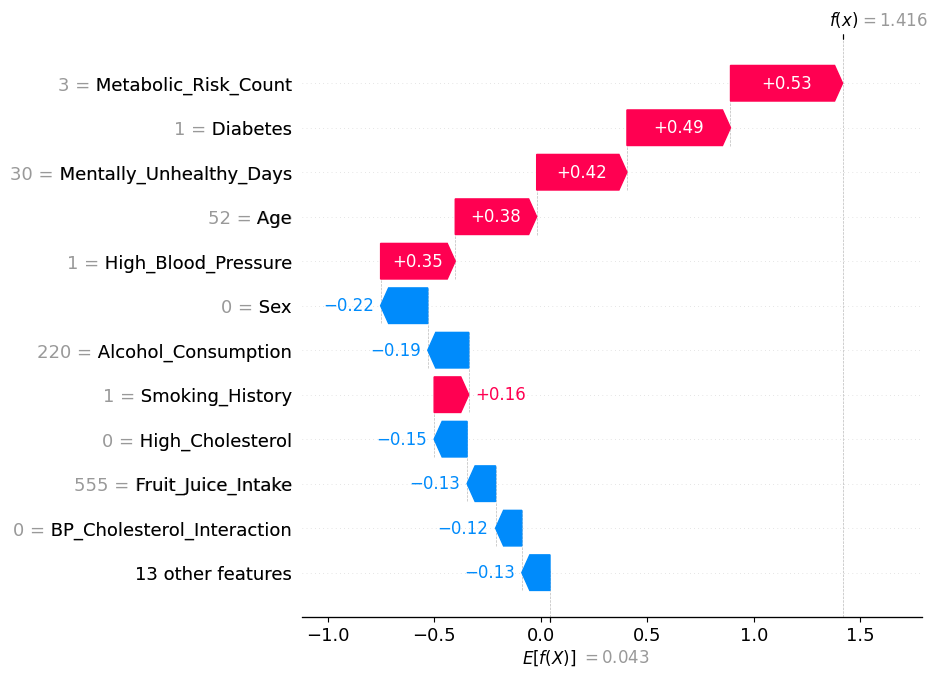

In [ ]:
positive_xgenai_result = predict_explain_with_xgenai(
    patient_values=positive_patient,
    top_n=12
)

In [ ]:
# import joblib
# import json
# import platform

# import sklearn
# import xgboost
# import pandas
# import numpy


# model_bundle = {
#     "logistic_model": final_logistic_model,
#     "random_forest_model": final_random_forest_model,
#     "xgboost_model": final_xgb_model,

#     "feature_names": list(final_features),

#     "ensemble_weights": {
#         "logistic": float(logistic_weight),
#         "random_forest": float(rf_weight),
#         "xgboost": float(xgb_weight),
#     },

#     "thresholds": {
#         "screening": float(screening_threshold),
#         "high_specificity": float(high_accuracy_threshold),
#     },

#     "model_version": "1.0.0",

#     "study_population": {
#         "minimum_age": 18,
#         "maximum_age": 55,
#     },
# }


# joblib.dump(
#     model_bundle,
#     "heart_risk_model_bundle.joblib"
# )


# environment_info = {
#     "python_version": platform.python_version(),
#     "scikit_learn_version": sklearn.__version__,
#     "xgboost_version": xgboost.__version__,
#     "pandas_version": pandas.__version__,
#     "numpy_version": numpy.__version__,
# }


# with open(
#     "model_environment.json",
#     "w",
#     encoding="utf-8"
# ) as file:
#     json.dump(
#         environment_info,
#         file,
#         indent=4
#     )


# print("Model bundle created successfully.")
# print("Features:", len(final_features))
# print("Environment:", environment_info)

In [ ]:
# from google.colab import files

# files.download("heart_risk_model_bundle.joblib")
# files.download("model_environment.json")

In [ ]:
import json

sample_index = X_test.index[0]

sample_features = (
    X_test.loc[sample_index, final_features]
    .astype(float)
    .to_dict()
)

test_request = {
    "features": sample_features
}

print(
    json.dumps(
        test_request,
        indent=2
    )
)

{
  "features": {
    "High_Blood_Pressure": 0.0,
    "Metabolic_Risk_Count": 0.0,
    "BP_Cholesterol_Interaction": 0.0,
    "Obesity": 0.0,
    "Diabetes": 0.0,
    "Lifestyle_Risk_Count": 0.0,
    "Smoking_History": 0.0,
    "Age": 28.0,
    "Mentally_Unhealthy_Days": 0.0,
    "Age_Smoking_Interaction": 0.0,
    "Moderate_Mental_Distress": 0.0,
    "High_Cholesterol": 0.0,
    "Time_Since_Cholesterol_Check": 5.0,
    "Sex": 1.0,
    "Alcohol_Consumption": 201.0,
    "Fruit_Intake": 303.0,
    "Current_Smoking": 0.0,
    "BMI": 28.21,
    "Age_BMI_Interaction": 789.88,
    "Overweight": 1.0,
    "Exercise": 1.0,
    "Other_Vegetable_Intake": 303.0,
    "Fruit_Juice_Intake": 555.0,
    "Green_Vegetable_Intake": 303.0
  }
}
